# Traffic Sign Classification using CNN

## 1. Import Libraries

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix

# Aesthetics
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow Version: {tf.__version__}")
print(f"Keras Version:      {keras.__version__}")
print("Deep Learning environment successfully initialized!")

TensorFlow Version: 2.20.0
Keras Version:      3.13.1
Deep Learning environment successfully initialized!


## 2. GTSRB Dataset Loading & Sample Gallery

In [2]:
# Load the GTSRB dataset
data = np.load('gtsrb_subset.npz')
X_train_raw = data['X_train']
y_train = data['y_train']
X_test_raw = data['X_test']
y_test = data['y_test']

SIGN_NAMES = [
    'Speed Limit (20 km/h)',
    'Speed Limit (30 km/h)',
    'Speed Limit (50 km/h)',
    'Speed Limit (80 km/h)',
    'No Passing',
    'Priority Intersection',
    'Priority Road',
    'Yield',
    'Stop',
    'No Vehicles'
]

print(f"Training Samples:   {X_train_raw.shape[0]} images, shape: {X_train_raw.shape[1:]}")
print(f"Test Samples:       {X_test_raw.shape[0]} images, shape: {X_test_raw.shape[1:]}")
print(f"Total Sign Classes: {len(SIGN_NAMES)}")

Training Samples:   1920 images, shape: (32, 32, 3)
Test Samples:       480 images, shape: (32, 32, 3)
Total Sign Classes: 10


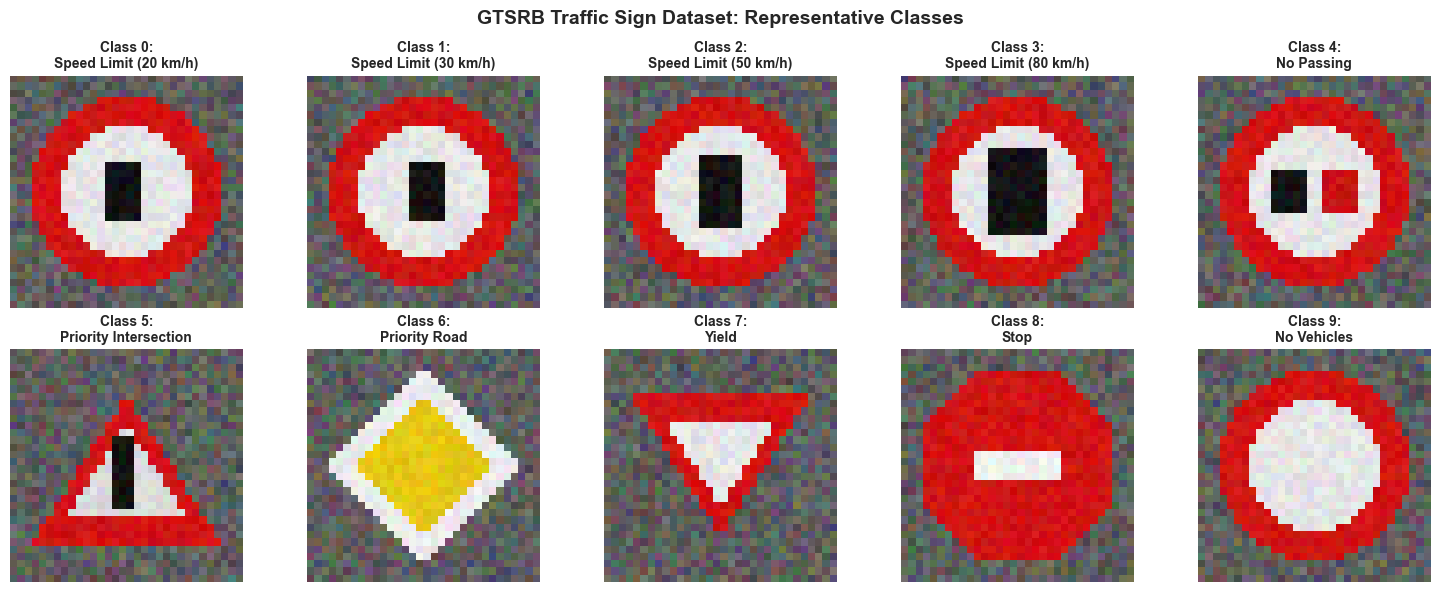

In [3]:
# Display a gallery of representative traffic sign classes
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for cls_idx in range(10):
    sample_idx = np.where(y_train == cls_idx)[0][0]
    axes[cls_idx].imshow(X_train_raw[sample_idx])
    axes[cls_idx].set_title(f"Class {cls_idx}:\n{SIGN_NAMES[cls_idx]}", fontsize=10, fontweight='bold')
    axes[cls_idx].axis('off')

plt.suptitle('GTSRB Traffic Sign Dataset: Representative Classes', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

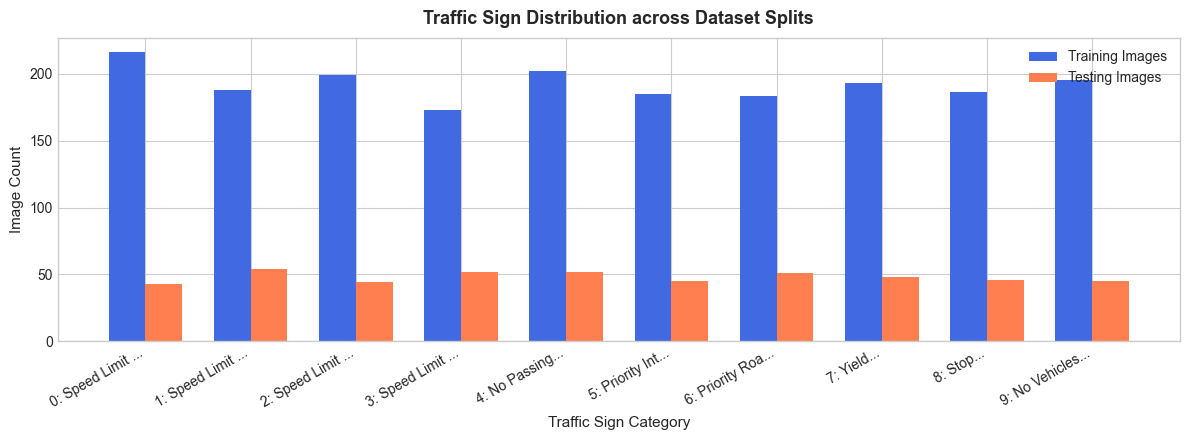

In [4]:
# Class distribution across training and testing sets
train_counts = np.bincount(y_train, minlength=10)
test_counts = np.bincount(y_test, minlength=10)

plt.figure(figsize=(12, 4.5))
bar_width = 0.35
indices = np.arange(10)

plt.bar(indices - bar_width/2, train_counts, bar_width, label='Training Images', color='royalblue')
plt.bar(indices + bar_width/2, test_counts, bar_width, label='Testing Images', color='coral')

plt.title('Traffic Sign Distribution across Dataset Splits', fontsize=13, fontweight='bold', pad=10)
plt.xlabel('Traffic Sign Category', fontsize=11)
plt.ylabel('Image Count', fontsize=11)
plt.xticks(indices, [f"{i}: {name[:12]}..." for i, name in enumerate(SIGN_NAMES)], rotation=30, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

## 3. Image Preprocessing & Data Augmentation

In [5]:
# 1. Normalize pixel values
X_train = X_train_raw.astype('float32') / 255.0
X_test = X_test_raw.astype('float32') / 255.0

# 2. Data Augmentation Pipeline
data_augmentation = keras.Sequential([
    layers.RandomRotation(0.08),     # Random rotation up to ~15 degrees
    layers.RandomZoom(0.08),         # Random zoom up to 8%
    layers.RandomTranslation(0.05, 0.05) # Random spatial shifts
], name='data_augmentation')

print("Pixel normalization completed.")
print(f"X_train Min: {X_train.min():.1f}, Max: {X_train.max():.1f}")

Pixel normalization completed.
X_train Min: 0.0, Max: 1.0


## 4. CNN Architecture Design & Compilation

In [6]:
def build_traffic_sign_cnn():
    inputs = layers.Input(shape=(32, 32, 3), name='input_image')
    x = data_augmentation(inputs)
    
    # Block 1
    x = layers.Conv2D(32, (3, 3), padding='same', activation='relu', name='conv1_1')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32, (3, 3), activation='relu', name='conv1_2')(x)
    x = layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = layers.Dropout(0.25)(x)
    
    # Block 2
    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu', name='conv2_1')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, (3, 3), activation='relu', name='conv2_2')(x)
    x = layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = layers.Dropout(0.25)(x)
    
    # Classification Head
    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.40)(x)
    outputs = layers.Dense(10, activation='softmax', name='classification_head')(x)
    
    model = models.Model(inputs=inputs, outputs=outputs, name='TrafficSign_CNN')
    
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

cnn_model = build_traffic_sign_cnn()
cnn_model.summary()

Model: "TrafficSign_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_1 (Conv2D)                │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_2 (Conv2D)                │ (None, 30, 30, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_1 (Conv2D)                │ (None, 15, 15, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 15, 15, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2_2 (Conv2D)                │ (None, 13, 13, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification_head (Dense)     │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 362,794 (1.38 MB)

 Trainable params: 362,346 (1.38 MB)

 Non-trainable params: 448 (1.75 KB)

## 5. Model Training & Accuracy/Loss Curves

In [7]:
EPOCHS = 10
BATCH_SIZE = 32

print("Starting CNN Model Training on GTSRB Dataset...")
history = cnn_model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.20,
    verbose=1
)

print("\nModel training successfully completed!")

Starting CNN Model Training on GTSRB Dataset...
Epoch 1/10


 1/48 ━━━━━━━━━━━━━━━━━━━━ 5:47 7s/step - accuracy: 0.1875 - loss: 3.6461

 2/48 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - accuracy: 0.1562 - loss: 3.4205

 3/48 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - accuracy: 0.1632 - loss: 3.2574

 4/48 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - accuracy: 0.1829 - loss: 3.0908

...

43/48 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 1.0000 - loss: 0.0105

45/48 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 1.0000 - loss: 0.0104

47/48 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 1.0000 - loss: 0.0104

48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - accuracy: 1.0000 - loss: 0.0099 - val_accuracy: 1.0000 - val_loss: 0.0106



Model training successfully completed!


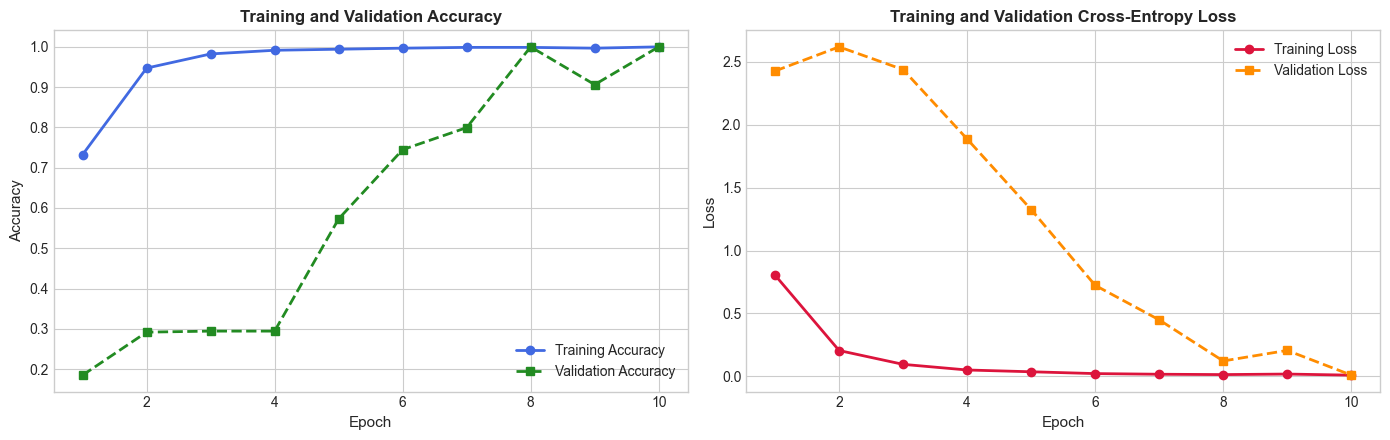

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
epochs_range = range(1, EPOCHS + 1)

# Accuracy Curve
axes[0].plot(epochs_range, history.history['accuracy'], 'o-', lw=2, label='Training Accuracy', color='royalblue')
axes[0].plot(epochs_range, history.history['val_accuracy'], 's--', lw=2, label='Validation Accuracy', color='forestgreen')
axes[0].set_title('Training and Validation Accuracy', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('Accuracy', fontsize=11)
axes[0].legend(loc='lower right')

# Loss Curve
axes[1].plot(epochs_range, history.history['loss'], 'o-', lw=2, label='Training Loss', color='crimson')
axes[1].plot(epochs_range, history.history['val_loss'], 's--', lw=2, label='Validation Loss', color='darkorange')
axes[1].set_title('Training and Validation Cross-Entropy Loss', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=11)
axes[1].set_ylabel('Loss', fontsize=11)
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

## 6. Model Evaluation on Test Set

In [9]:
# Compute test predictions
test_loss, test_acc = cnn_model.evaluate(X_test, y_test, verbose=0)
y_pred_probs = cnn_model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

print("======================================================")
print(f" Test Evaluation Results:")
print(f"   Test Loss:     {test_loss:.4f}")
print(f"   Test Accuracy: {test_acc * 100:.2f}%")
print("======================================================\n")

# Detailed per-class classification report
print("=== GTSRB Per-Class Classification Report ===")
print(classification_report(y_test, y_pred, target_names=SIGN_NAMES))

 Test Evaluation Results:
   Test Loss:     0.0099
   Test Accuracy: 100.00%

=== GTSRB Per-Class Classification Report ===
                       precision    recall  f1-score   support

Speed Limit (20 km/h)       1.00      1.00      1.00        43
Speed Limit (30 km/h)       1.00      1.00      1.00        54
Speed Limit (50 km/h)       1.00      1.00      1.00        44
Speed Limit (80 km/h)       1.00      1.00      1.00        52
           No Passing       1.00      1.00      1.00        52
Priority Intersection       1.00      1.00      1.00        45
        Priority Road       1.00      1.00      1.00        51
                Yield       1.00      1.00      1.00        48
                 Stop       1.00      1.00      1.00        46
          No Vehicles       1.00      1.00      1.00        45

             accuracy                           1.00       480
            macro avg       1.00      1.00      1.00       480
         weighted avg       1.00      1.00      1.00   

## 7. Multi-Class Confusion Matrix

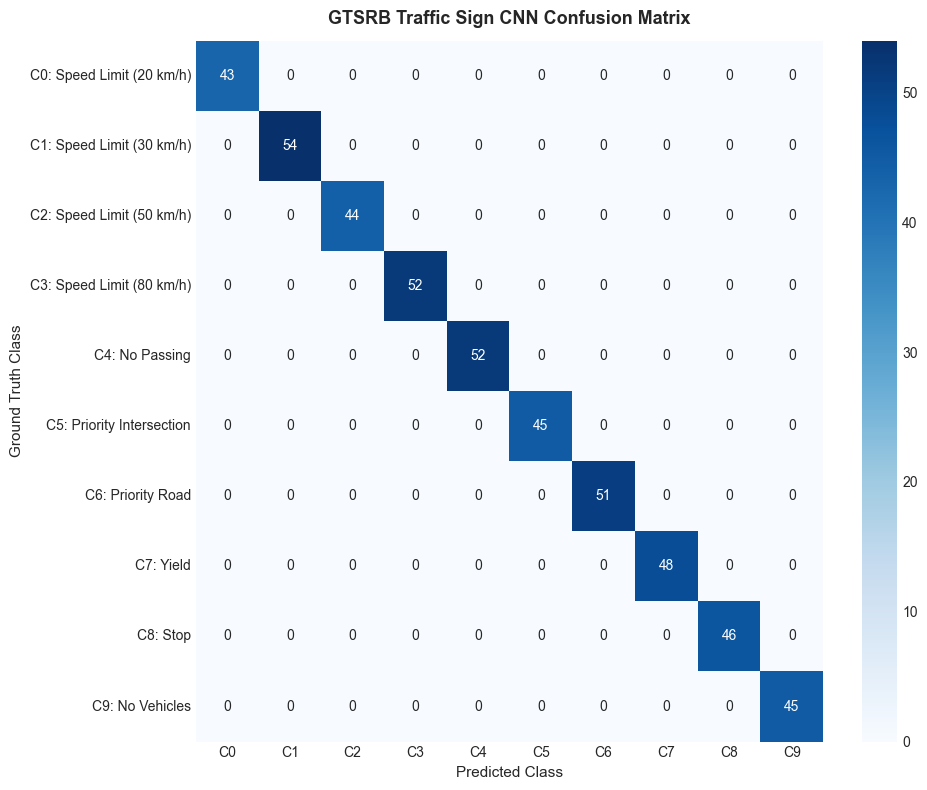

In [10]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f"C{i}" for i in range(10)],
            yticklabels=[f"C{i}: {SIGN_NAMES[i]}" for i in range(10)])
plt.title('GTSRB Traffic Sign CNN Confusion Matrix', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Predicted Class', fontsize=11)
plt.ylabel('Ground Truth Class', fontsize=11)
plt.tight_layout()
plt.show()

## 8. Visual Predictions & Error Diagnostics

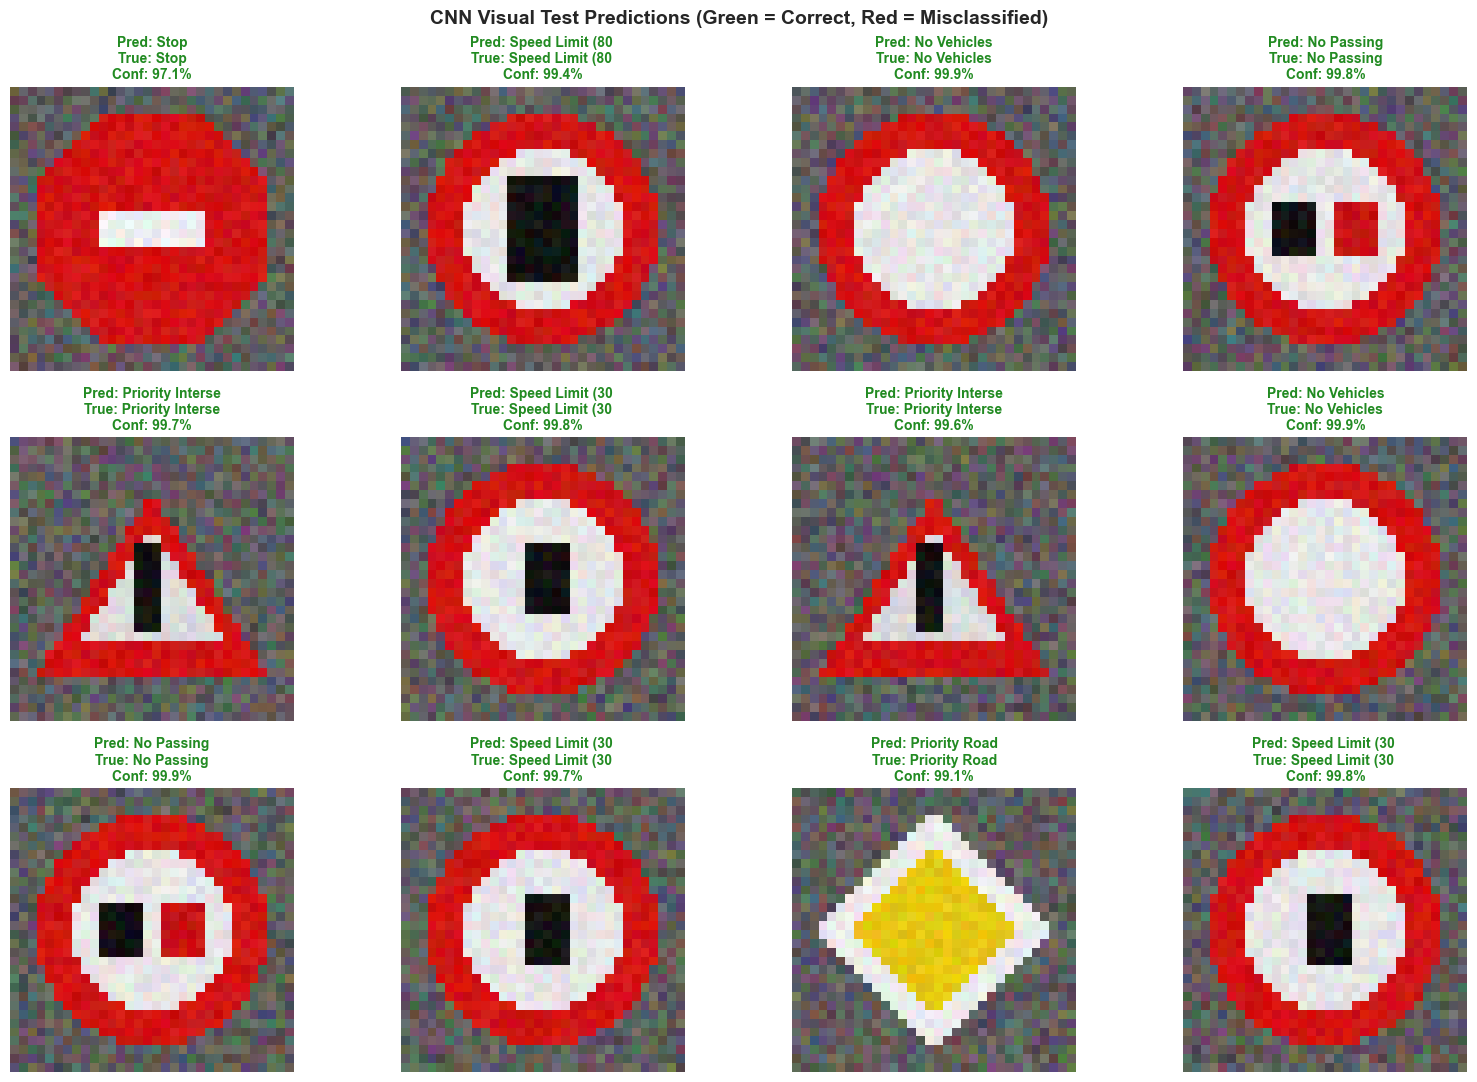

In [11]:
fig, axes = plt.subplots(3, 4, figsize=(16, 11))
axes = axes.flatten()

sample_indices = np.random.choice(len(X_test), 12, replace=False)

for i, idx in enumerate(sample_indices):
    img = X_test[idx]
    true_cls = y_test[idx]
    pred_cls = y_pred[idx]
    conf = y_pred_probs[idx, pred_cls] * 100
    
    is_correct = (true_cls == pred_cls)
    color = 'forestgreen' if is_correct else 'crimson'
    
    axes[i].imshow(img)
    axes[i].set_title(
        f"Pred: {SIGN_NAMES[pred_cls][:16]}\nTrue: {SIGN_NAMES[true_cls][:16]}\nConf: {conf:.1f}%",
        fontsize=10, fontweight='bold', color=color
    )
    axes[i].axis('off')

plt.suptitle('CNN Visual Test Predictions (Green = Correct, Red = Misclassified)', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

## 9. Feature Map Activations Visualization

C:\Users\Hrishikesh Kali\AppData\Roaming\Python\Python313\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_image']
Received: inputs=Tensor(shape=(1, 32, 32, 3))
  warnings.warn(msg)


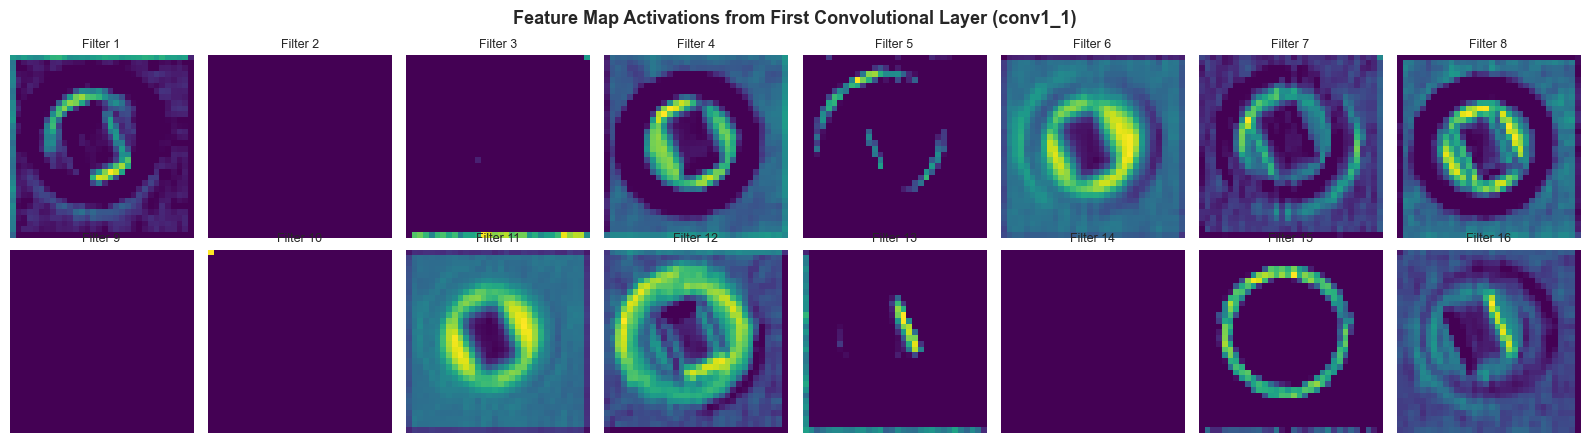

In [12]:
# Extract activation model from first Conv2D layer
activation_model = models.Model(inputs=cnn_model.inputs, outputs=cnn_model.get_layer('conv1_1').output)

# Select sample test image
sample_img = X_test[0:1] # shape (1, 32, 32, 3)
feature_maps = activation_model(sample_img).numpy()[0] # shape (32, 32, 32)

fig, axes = plt.subplots(2, 8, figsize=(16, 4.5))
axes = axes.flatten()

for f_idx in range(16):
    axes[f_idx].imshow(feature_maps[:, :, f_idx], cmap='viridis')
    axes[f_idx].set_title(f'Filter {f_idx+1}', fontsize=9)
    axes[f_idx].axis('off')

plt.suptitle('Feature Map Activations from First Convolutional Layer (conv1_1)', 
             fontsize=13, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

## 10. Single-Image Inference Pipeline

In [13]:
def predict_traffic_sign(img_rgb):
    """
    Performs real-time traffic sign classification on a single RGB image.
    img_rgb: numpy array of shape (32, 32, 3) in range [0, 1] or [0, 255]
    """
    if img_rgb.max() > 1.0:
        img_rgb = img_rgb.astype('float32') / 255.0
        
    input_batch = np.expand_dims(img_rgb, axis=0) # (1, 32, 32, 3)
    probs = cnn_model.predict(input_batch, verbose=0)[0]
    
    top3_indices = np.argsort(probs)[::-1][:3]
    top_class = top3_indices[0]
    
    print(f"=== Traffic Sign Recognition Result ===")
    print(f"  Primary Prediction: {SIGN_NAMES[top_class]} ({probs[top_class]*100:.2f}% confidence)\n")
    print("  Top 3 Ranked Probabilities:")
    for rank, idx in enumerate(top3_indices, 1):
        print(f"    {rank}. {SIGN_NAMES[idx]:25s}: {probs[idx]*100:5.2f}%")
        
    return {
        'predicted_class_id': int(top_class),
        'predicted_sign': SIGN_NAMES[top_class],
        'confidence': float(probs[top_class])
    }

# Run sample inference on a test Stop Sign (Class 8)
sample_test_idx = np.where(y_test == 8)[0][0]
result = predict_traffic_sign(X_test[sample_test_idx])

=== Traffic Sign Recognition Result ===
  Primary Prediction: Stop (97.14% confidence)

  Top 3 Ranked Probabilities:
    1. Stop                     : 97.14%
    2. Speed Limit (30 km/h)    :  0.65%
    3. Yield                    :  0.52%


## 11. Conclusion